# Non-reasoning models

#### without sampling

Models used: 

A: Qwen2.5-1.5B-Instruct

B: Qwen2.5-7B-Instruct 

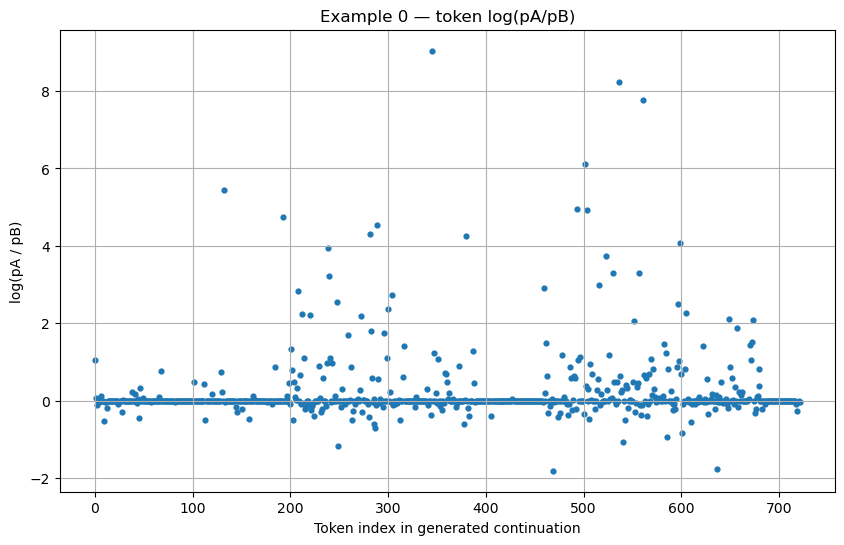

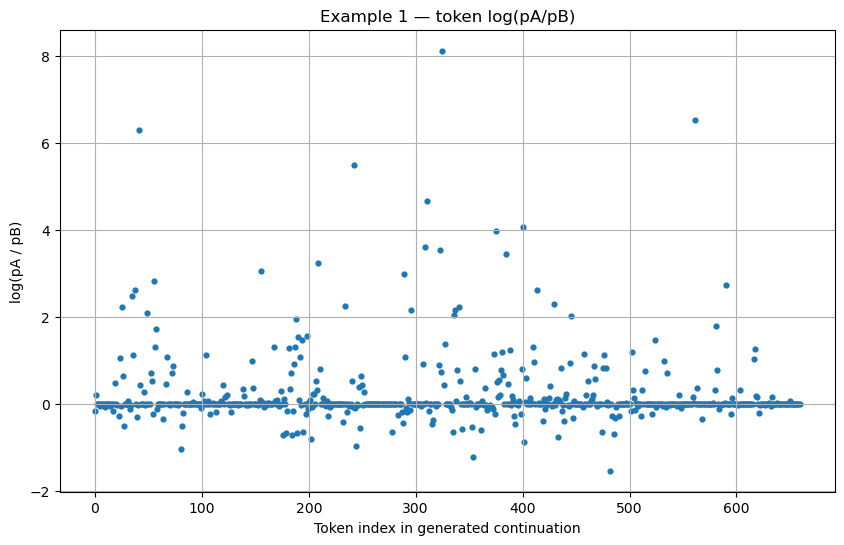

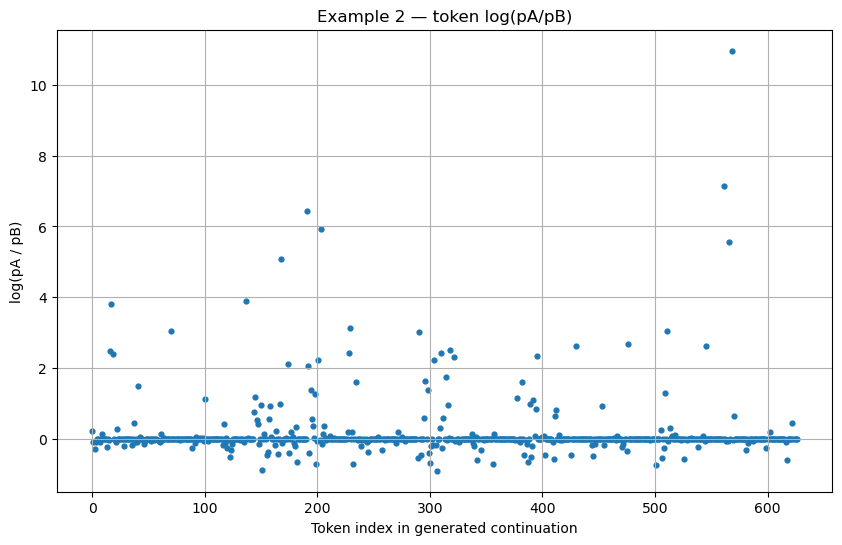

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

path = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen2_5-1_5B-Instruct_vs_Qwen2_5-7B-Instruct_1768314942.csv"
df = pd.read_csv(path)

df["log_ratio"] = np.log(df["ratio_pA_over_pB"].replace([np.inf, -np.inf], np.nan))
df = df.dropna(subset=["log_ratio"])
df[["seed","example_id","token_idx","ratio_pA_over_pB","log_ratio"]].head()

for ex_id, g in df.groupby("example_id"):
    plt.figure(figsize=(10,6))
    plt.title(f"Example {ex_id} — token log(pA/pB)")
    plt.scatter(g["token_idx"], g["log_ratio"], s=12)
    #plt.axhline(g["log_ratio"].mean(), linewidth=1)
    plt.xlabel("Token index in generated continuation")
    plt.ylabel("log(pA / pB)")
    plt.grid(True)
    plt.show()